In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


In [12]:

# Cargar los datos desde el archivo CSV
datos = pd.read_csv("datos_ventas.csv")

# Visualizar las primeras filas para ver la estructura
print(datos.head())

# Opcional: Verificar datos faltantes y el tipo de datos
print(datos.info())


       mes  unidades_vendidas  precio_venta  precio_compra
0  2024-01                120          15.5           10.0
1  2024-02                150          15.7           10.1
2  2024-03                170          15.8           10.2
3  2024-04                160          15.6           10.1
4  2024-05                180          15.9           10.3
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   mes                12 non-null     object 
 1   unidades_vendidas  12 non-null     int64  
 2   precio_venta       12 non-null     float64
 3   precio_compra      12 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 516.0+ bytes
None


In [13]:
# Seleccionamos las columnas necesarias
datos["mes"] = pd.to_datetime(datos["mes"]).dt.month  # Convertimos la fecha a mes numérico si es una fecha completa
# Agregar una columna de ganancia a los datos históricos
datos["ganancia"] = (datos["precio_venta"] - datos["precio_compra"]) * datos["unidades_vendidas"]


# Definimos las variables predictoras (X) y las variables objetivo (y)
X = datos[["mes", "precio_venta"]]
y_unidades = datos["unidades_vendidas"]
y_precio = datos["precio_venta"]


# Entrenar el modelo para predecir precio_compra en función de mes y precio_venta
X_compra = datos[["mes", "precio_venta"]]
y_compra = datos["precio_compra"]



In [14]:
# División de los datos
X_train, X_test, y_unidades_train, y_unidades_test = train_test_split(X, y_unidades, test_size=0.2, random_state=42)
_, _, y_precio_train, y_precio_test = train_test_split(X, y_precio, test_size=0.2, random_state=42)


# Dividimos los datos
X_compra_train, X_compra_test, y_compra_train, y_compra_test = train_test_split(X_compra, y_compra, test_size=0.2, random_state=42)




In [15]:
# Modelo para predecir unidades a comprar
modelo_unidades = LinearRegression()
modelo_unidades.fit(X_train, y_unidades_train)

# Modelo para predecir precio de venta
modelo_precio = LinearRegression()
modelo_precio.fit(X_train, y_precio_train)


# Crear el modelo de precio_compra
modelo_compra = LinearRegression()
modelo_compra.fit(X_compra_train, y_compra_train)



LinearRegression()

In [16]:

# Definimos el mes a predecir
nuevo_mes = pd.DataFrame({"mes": [20], "precio_venta": [y_precio.mean()]})

# Predicción de unidades
unidades_pred = modelo_unidades.predict(nuevo_mes)
print(f"Unidades recomendadas para comprar: {unidades_pred[0]:.0f}")

# Predicción del precio de venta
precio_venta_pred = modelo_precio.predict(nuevo_mes)
print(f"Precio de venta recomendado: {precio_venta_pred[0]:.2f}")



Unidades recomendadas para comprar: 303
Precio de venta recomendado: 16.00


In [17]:

# Definimos el mes para el cual queremos predecir el precio de compra óptimo
nuevo_mes_precio_compra = pd.DataFrame({"mes": [15], "precio_venta": [y_precio.mean()]})

# Predicción del precio de compra óptimo
precio_compra_optimo = modelo_compra.predict(nuevo_mes_precio_compra)
print(f"Precio de compra óptimo recomendado para el mes escogido: {precio_compra_optimo[0]:.2f}")


Precio de compra óptimo recomendado para el mes escogido: 10.58


In [18]:
# Evaluación del modelo de unidades
mse_unidades = mean_squared_error(y_unidades_test, modelo_unidades.predict(X_test))
print("Error cuadrático medio para unidades:", mse_unidades)

# Evaluación del modelo de precio de venta
mse_precio = mean_squared_error(y_precio_test, modelo_precio.predict(X_test))
print("Error cuadrático medio para precio de venta:", mse_precio)


# Evaluación del modelo de precio de compra
mse_compra = mean_squared_error(y_compra_test, modelo_compra.predict(X_compra_test))
print("Error cuadrático medio para precio de compra:", mse_compra)



Error cuadrático medio para unidades: 323.977825386826
Error cuadrático medio para precio de venta: 4.2072581611787294e-30
Error cuadrático medio para precio de compra: 0.0062810423580479295


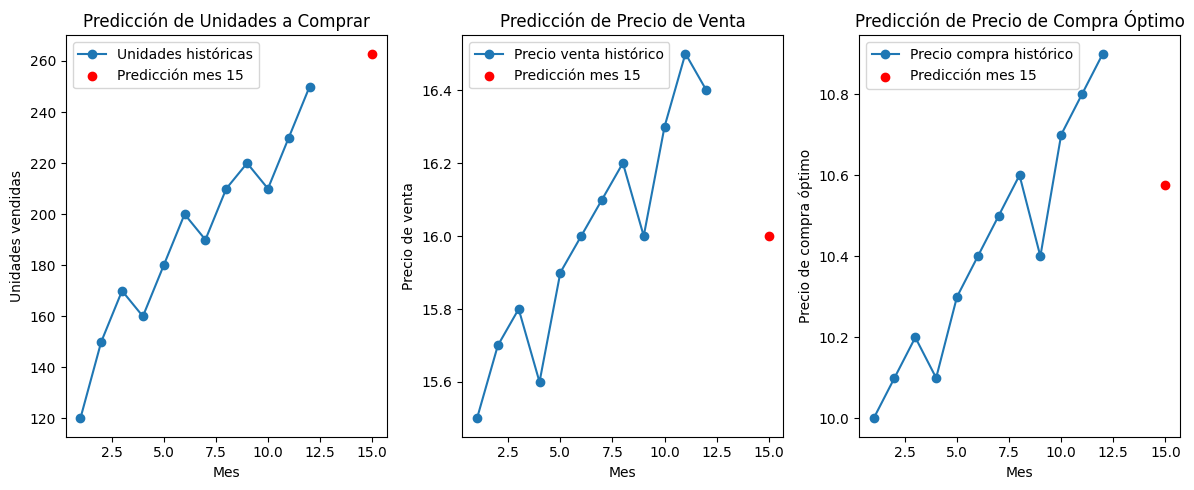

In [20]:
# Predicciones para el mes 15
nuevo_mes_pred = pd.DataFrame({"mes": [15], "precio_venta": [y_precio.mean()]})
unidades_pred = modelo_unidades.predict(nuevo_mes_pred)[0]
precio_venta_pred = modelo_precio.predict(nuevo_mes_pred)[0]
precio_compra_optimo = modelo_compra.predict(nuevo_mes_pred)[0]

# 1. Gráfico de Unidades vendidas y predicción
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.plot(datos["mes"], datos["unidades_vendidas"], label="Unidades históricas", marker='o')
plt.scatter(15, unidades_pred, color="red", label="Predicción mes 15")
plt.xlabel("Mes")
plt.ylabel("Unidades vendidas")
plt.title("Predicción de Unidades a Comprar")
plt.legend()

# 2. Gráfico de Precio de Venta y predicción
plt.subplot(1, 3, 2)
plt.plot(datos["mes"], datos["precio_venta"], label="Precio venta histórico", marker='o')
plt.scatter(15, precio_venta_pred, color="red", label="Predicción mes 15")
plt.xlabel("Mes")
plt.ylabel("Precio de venta")
plt.title("Predicción de Precio de Venta")
plt.legend()

# 3. Gráfico de Precio de Compra óptimo y predicción
plt.subplot(1, 3, 3)
plt.plot(datos["mes"], datos["precio_compra"], label="Precio compra histórico", marker='o')
plt.scatter(15, precio_compra_optimo, color="red", label="Predicción mes 15")
plt.xlabel("Mes")
plt.ylabel("Precio de compra óptimo")
plt.title("Predicción de Precio de Compra Óptimo")
plt.legend()

# Mostrar gráficos
plt.tight_layout()
plt.show()
